In [34]:
# load necessary libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from transformers import BertTokenizer
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import defaultdict
from pathlib import Path

#project_root = Path(__file__).resolve().parents[3]
project_root = Path.cwd() / "../"
sys.path.append(str(project_root))

from utils.clustering import (
    TripletDataset, TripletDatasetHN, ModelMask,
    generate_triplets, generate_triplets_heuristic_hn, generate_triplets_hn,
    train_triplet, train_triplet_hn
)

# load the dictionary terms
groups_dictionary = pd.read_excel("../01_data/dictionary/groups_dictionary_cl.xlsx")

In [4]:
# create a single list of all dictionary entries paired with their category
mention_list = []
category_list = []
categories = groups_dictionary.columns
cat2id = {c: i for i, c in enumerate(categories)}
for category in categories:
    for idx, row in groups_dictionary[[category]].iterrows():
        if not pd.isna(row.values):
            entry = row.values[0]
            mention_list.append(entry.strip())
            category_list.append(category)

category_list = [cat for cat in category_list]

df = pd.DataFrame({'mention': mention_list, 'category': category_list})

mention_list = df["mention"].to_list()
category_list = df["category"].to_list()

In [5]:
# custom list of semantically close groups to perform hard negative mining based on heuristic
close_groups = [("patients", "people with disabilities"), ("law-enforcement personnel", "military personnel"), ("men", "women"),
                ("upper class", "middle class"), ("crime victims", "criminals"), ("landlords", "homeowners and landowners", "tenants"),
                ("caregivers", "health professionals")]
close_map = defaultdict(list)
for group in close_groups:
    for c in group:
        close_map[c] = [x for x in group if x != c]

In [13]:
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = ModelMask(tokenizer).to(device)
optimizer = optim.AdamW(model.parameters(), lr=2e-5)
loss_fn = nn.TripletMarginLoss(margin=1.0, p=2)
num_epochs = 25
for epoch in range(num_epochs):
    triplets = generate_triplets(df)
    dataset = TripletDataset(triplets, tokenizer)
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
    loss = train_triplet(model, dataloader, loss_fn, optimizer, device)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Training: 100%|██████████| 23/23 [00:09<00:00,  2.42it/s]


Epoch 1, Loss: 0.7514


Training: 100%|██████████| 23/23 [00:08<00:00,  2.58it/s]


Epoch 2, Loss: 0.4644


Training: 100%|██████████| 23/23 [00:08<00:00,  2.62it/s]


...

Epoch 23, Loss: 0.0416


Training: 100%|██████████| 23/23 [00:08<00:00,  2.61it/s]


Epoch 24, Loss: 0.0353


Training: 100%|██████████| 23/23 [00:08<00:00,  2.60it/s]

Epoch 25, Loss: 0.0453


In [15]:
def get_mask_embeddings(model, mentions, tokenizer, device, max_len=128, batch_size=32):

    model.eval()
    all_embeddings = []
    mask_token = tokenizer.mask_token
    mask_id = tokenizer.mask_token_id

    with torch.no_grad():
        for start in range(0, len(mentions), batch_size):
            batch_mentions = mentions[start:start+batch_size]
            batch_texts = []
            for m in batch_mentions:
                text = f"Social group of {m} is {mask_token}"
                batch_texts.append(text)
            
            enc = tokenizer(
                batch_texts,
                padding='max_length',
                truncation=True,
                max_length=max_len,
                return_tensors='pt'
            )

            input_ids = enc['input_ids'].to(device)
            attention_mask = enc['attention_mask'].to(device)

            outputs = model.encoder(input_ids=input_ids, attention_mask=attention_mask)
            hidden = outputs.last_hidden_state

            mask_positions = (input_ids == mask_id)

            batch_embs = []
            for i in range(input_ids.size(0)):
                pos = mask_positions[i]
                if pos.any():
                    # average if multiple mask tokens (or single)
                    emb = hidden[i][pos].mean(dim=0)
                else:
                    # fallback (shouldn't happen if template guaranteed), use CLS
                    emb = hidden[i][0]
                batch_embs.append(emb)

            h = torch.stack(batch_embs)

            # project and normalize (same as training)
            z = model.projector(h.to(next(model.parameters()).device))
            z = F.normalize(z, p=2, dim=1)

            all_embeddings.append(z.cpu())

    return torch.cat(all_embeddings, dim=0)

mention_embeddings = get_mask_embeddings(model, mention_list, tokenizer, device)
labels_np = np.array([cat2id[cat] for cat in category_list])

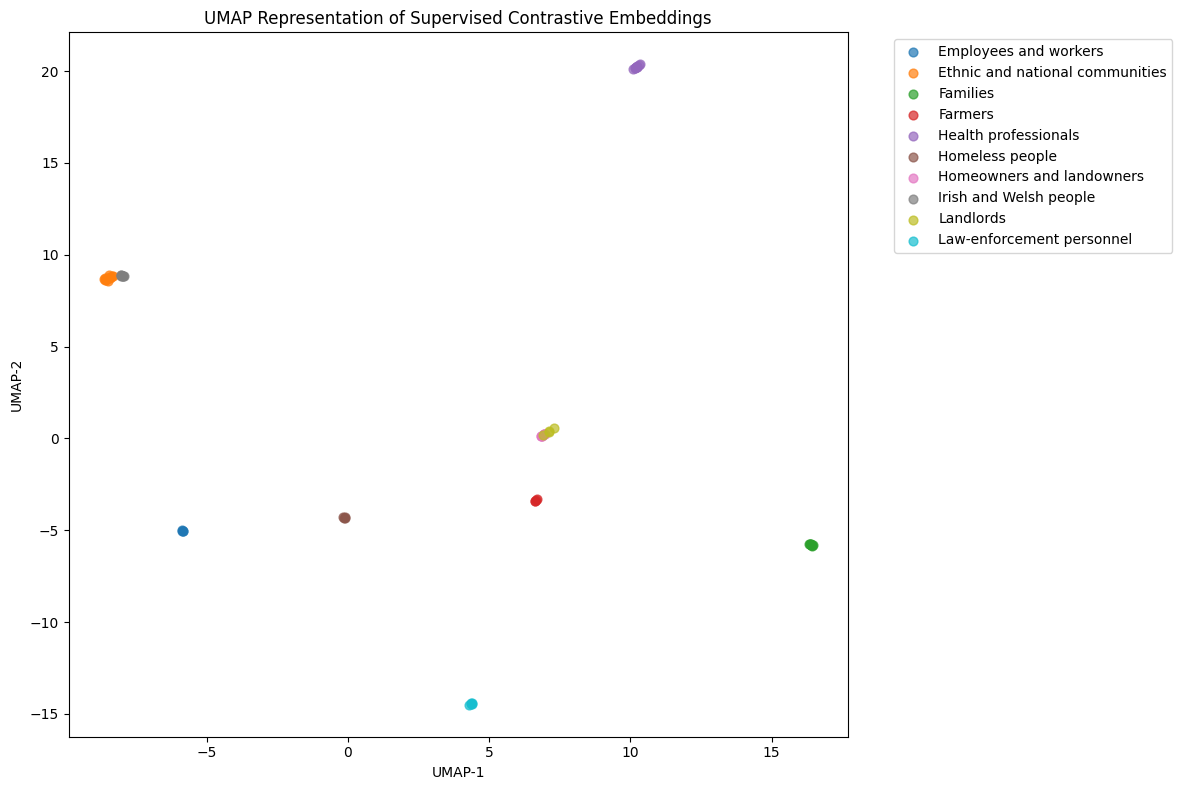

In [16]:
reducer = umap.UMAP(n_components=2)
emb_2d = reducer.fit_transform(mention_embeddings)

plt.figure(figsize=(12, 8))
categories = list(cat2id.keys())
num_classes = len(categories)

for c in range(10, 20):
    idx = np.where(labels_np == c)[0]
    if len(idx) == 0:
        continue
    plt.scatter(
        emb_2d[idx, 0],
        emb_2d[idx, 1],
        label=categories[c],
        alpha=0.7,
        s=40
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP Representation of Supervised Contrastive Embeddings")
plt.tight_layout()
plt.show()

Best k by BIC: 39


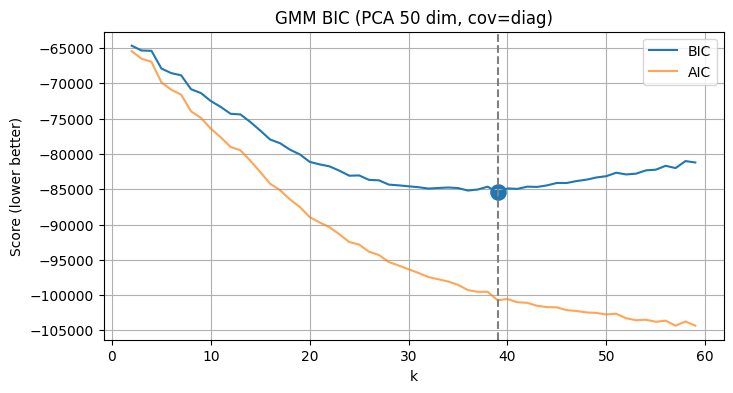

In [93]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

X = mention_embeddings.cpu().numpy()
pca = PCA(n_components=50, random_state=0)
X_red = pca.fit_transform(X)

ks = range(2, 60)
bics = []
aics = []
cov_type = 'diag'
for k in ks:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=cov_type,
        random_state=7,
        n_init=5,
        reg_covar=1e-6,
        max_iter=500
    )
    gmm.fit(X_red)
    bics.append(gmm.bic(X_red))
    aics.append(gmm.aic(X_red))

bics = np.array(bics)
best_idx = bics.argmin()
best_k = ks[best_idx]
print("Best k by BIC:", best_k)

plt.figure(figsize=(8,4))
plt.plot(list(ks), bics, label='BIC')
plt.plot(list(ks), aics, label='AIC', alpha=0.7)
plt.axvline(best_k, color='gray', linestyle='--')
plt.scatter([best_k], [bics[best_idx]], s=120)
plt.xlabel('k')
plt.ylabel('Score (lower better)')
plt.title(f'GMM BIC (PCA {X_red.shape[1]} dim, cov={cov_type})')
plt.legend()
plt.grid(True)
plt.show()



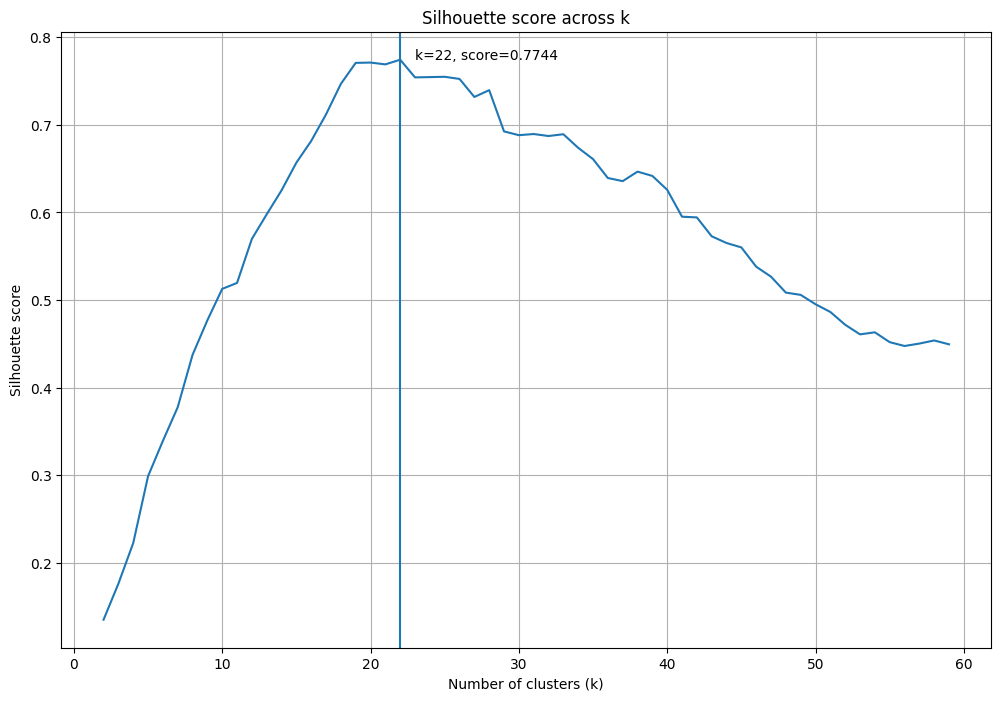

In [85]:
X = mention_embeddings.numpy()
pca = PCA(n_components=50, random_state=0)
X_red = pca.fit_transform(X)

num_potential_clusters = 60

all_scores = []

for k in range(2, num_potential_clusters):
    kmeans = KMeans(n_clusters=k, random_state=7)
    pred_labels = kmeans.fit_predict(X)
    all_scores.append(silhouette_score(X, pred_labels))

ks = list(range(2, num_potential_clusters))
scores = np.array(all_scores)

best_idx = scores.argmax()
best_k = ks[best_idx]
best_score = scores[best_idx]

plt.figure(figsize=(12, 8))
plt.plot(ks, scores)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score across k")
plt.grid(True)

# Highlight max point
plt.axvline(best_k)
plt.annotate(
    f"k={best_k}, score={best_score:.4f}",
    xy=(best_k, best_score),
    xytext=(best_k + 1, best_score),
)

plt.show()

In [94]:
X = mention_embeddings.numpy()
reducer = PCA(n_components=50, random_state=0)
#reducer = umap.UMAP(n_components=10)
X_red = reducer.fit_transform(X)

k = len(set(categories))
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(X_red)

cluster_labels = kmeans.labels_

df['cluster'] = cluster_labels

clusters = df['cluster'].unique()
cluster2cat = {c: df[df['cluster']==c]['category'].tolist() for c in clusters}
sorted_dict = dict(sorted(cluster2cat.items()))
sorted_dict

{0: ['LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI'],
 1: ['Employers and business owners',
  'Employers and business owners',
  'Employers and business owners',
  'Employers and business owners',
  'White collar workers'],
 2: ['Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees'],
 3: ['Elderly people',
  'Elderly people',
  'Elderly people',
  'Elderly people',
  'Elderly people',
  'Elderly people',
  'Elderly people',
  'Elderly people'],
 4: ['Manual and service workers',
  'Manual and service workers',
  'Manual and service workers',
  'Manual and service workers',
  'Manual and service workers',
  'Manual and s

In [24]:
# import all mentions
with open("../01_data/annotations/annotations_no_augmentations.json") as f:
    all_annotations = json.load(f)

# get all individual group mentions
flat_mentions = [ann["text"] for task in all_annotations for ann in task["annotations"] if task["annotations"]]

# pass them through the model
all_embeddings = get_mask_embeddings(model, flat_mentions, tokenizer, device)

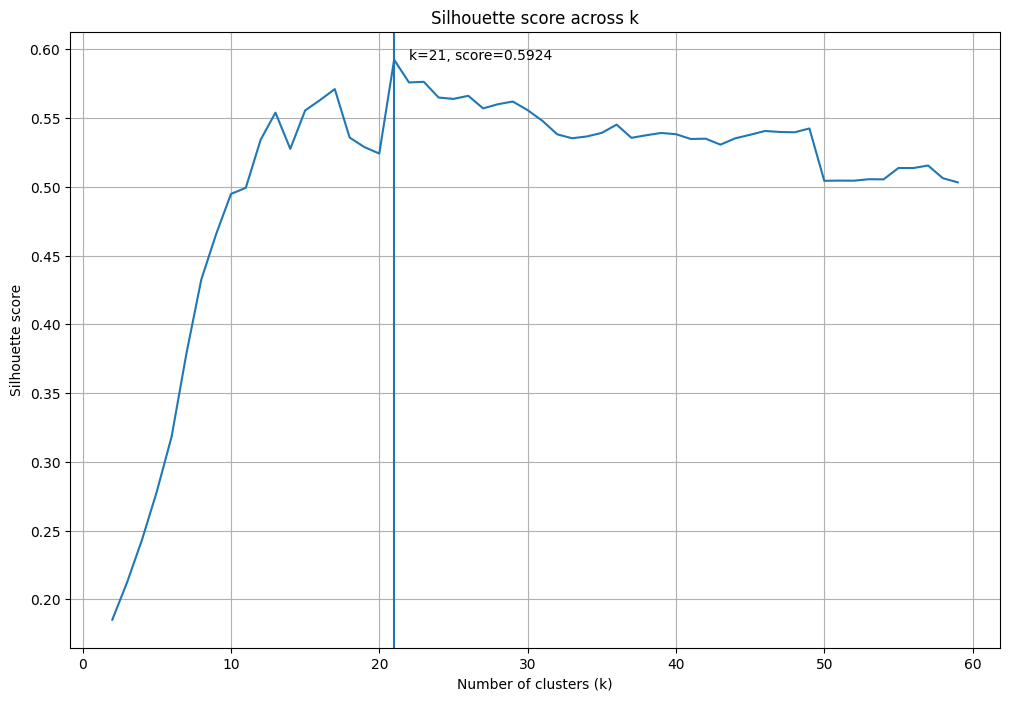

In [95]:
X = all_embeddings.numpy()

# reduce dimension further if wanted
reducer = PCA(n_components=50, random_state=0)
#reducer = umap.UMAP(n_components=10)
X_red = reducer.fit_transform(X)

num_potential_clusters = 60

all_scores = []

for k in range(2, num_potential_clusters):
    kmeans = KMeans(n_clusters=k, random_state=7)
    pred_labels = kmeans.fit_predict(X_red)
    all_scores.append(silhouette_score(X_red, pred_labels))

ks = list(range(2, num_potential_clusters))
scores = np.array(all_scores)

best_idx = scores.argmax()
best_k = ks[best_idx]
best_score = scores[best_idx]

plt.figure(figsize=(12, 8))
plt.plot(ks, scores)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score across k")
plt.grid(True)

# Highlight max point
plt.axvline(best_k)
plt.annotate(
    f"k={best_k}, score={best_score:.4f}",
    xy=(best_k, best_score),
    xytext=(best_k + 1, best_score),
)

plt.show()

In [96]:
X = all_embeddings.numpy()
kmeans = KMeans(n_clusters=49, random_state=7)
labels = kmeans.fit_predict(X)
cluster_df = pd.DataFrame({"group mention": flat_mentions,
                           "cluster": labels})

clusters = cluster_df['cluster'].unique()
cluster2cat = {c: cluster_df[cluster_df['cluster']==c]['group mention'].tolist() for c in clusters}
sorted_dict = dict(sorted(cluster2cat.items()))
sorted_dict

{0: ['children',
  'every child',
  'child',
  'child',
  'child',
  'children',
  'children living in poverty',
  'any child under the age of 18',
  'every child',
  'the children and their families most in need',
  'children',
  'those children who have special educational needs',
  'these children',
  'those children',
  'children',
  'child',
  'child',
  'children from the poorest backgrounds',
  'children',
  'children',
  'children',
  'every child',
  'Children',
  'children in families',
  'children living in poverty',
  'child',
  'child',
  'children',
  'child',
  'child',
  'child',
  'Children',
  'child',
  'Children',
  'children',
  'Children',
  'child',
  'children',
  'child',
  'child',
  'child',
  'Child',
  'child',
  'children with special educational needs',
  'children',
  'children and their families from the wider middle east and north Africa area',
  'child',
  'child',
  'children',
  'child',
  'children from Greenwich',
  'the recipients of universal cr